In [1]:
!pip install datasets

In [2]:
from datasets import load_dataset
dataset = load_dataset("mishrasiddhant911/online-retail-II")

online_retail_II.csv: reconstructing file:   0%|          |  0.00B / 94.9MB            

online_retail_II.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1067371 [00:00<?, ? examples/s]

In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country'],
        num_rows: 1067371
    })
})

In [5]:
df = dataset["train"].to_pandas()

In [6]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
df.shape

(1067371, 8)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [9]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [10]:
(df.isnull().sum() / len(df) * 100).round(2)

,0
Invoice,0.00
StockCode,0.00
Description,0.41
Quantity,0.00
InvoiceDate,0.00
Price,0.00
Customer ID,22.77
Country,0.00


In [11]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [12]:
df_clean = df.dropna(subset=["Customer ID"]).copy()

In [13]:
df_clean.shape

(824364, 8)

In [14]:
df_clean.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


In [15]:
df_clean.duplicated().sum()

np.int64(26479)

In [16]:
df_clean["Quantity"].describe()

,Quantity
count,824364.000000
mean,12.414574
std,188.976099
min,-80995.000000
25%,2.000000
50%,5.000000
75%,12.000000
max,80995.000000


In [17]:
df_clean["Price"].describe()

,Price
count,824364.000000
mean,3.676800
std,70.241388
min,0.000000
25%,1.250000
50%,1.950000
75%,3.750000
max,38970.000000


In [18]:

(df_clean["Quantity"] < 0).sum()

np.int64(18744)

In [19]:

(df_clean["Quantity"] == 0).sum()

np.int64(0)

In [20]:

(df_clean["Price"] == 0).sum()

np.int64(71)

In [21]:

df_clean["Invoice"].astype(str).str.startswith("C").sum()

np.int64(18744)

In [22]:
df_sales = df_clean[
    (~df_clean["Invoice"].astype(str).str.startswith("C")) &
    (df_clean["Quantity"] > 0) &
    (df_clean["Price"] > 0)
].copy()

In [23]:
df_sales["Revenue"] = df_sales["Quantity"] * df_sales["Price"]

In [24]:
df_sales.shape

(805549, 9)

In [25]:
df_sales.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [26]:
df_sales["Revenue"].sum()

np.float64(17743429.178000003)

In [27]:
df_sales["Customer ID"].nunique()

5878

In [28]:
df_sales["StockCode"].nunique()

4631

In [29]:
df_sales["Country"].nunique()

41

In [30]:
df_sales["Invoice"].nunique()

36969

In [33]:
import pandas as pd
df_sales["InvoiceDate"] = pd.to_datetime(df_sales["InvoiceDate"])

In [34]:
df_sales["InvoiceDate"].dtype

dtype('<M8[ns]')

In [35]:
print("Start Date:", df_sales["InvoiceDate"].min())
print("End Date:", df_sales["InvoiceDate"].max())

Start Date: 2009-12-01 07:45:00
End Date: 2011-12-09 12:50:00


In [36]:
df_sales["Month"] = df_sales["InvoiceDate"].dt.to_period("M")

In [37]:
monthly_revenue = df_sales.groupby("Month")["Revenue"].sum()

In [38]:
monthly_revenue

,Revenue
Month,
2009-12,686654.160
2010-01,557319.062
2010-02,506371.066
2010-03,699608.991
2010-04,594609.192
2010-05,599985.790
2010-06,639066.580
2010-07,591636.740
2010-08,604242.650


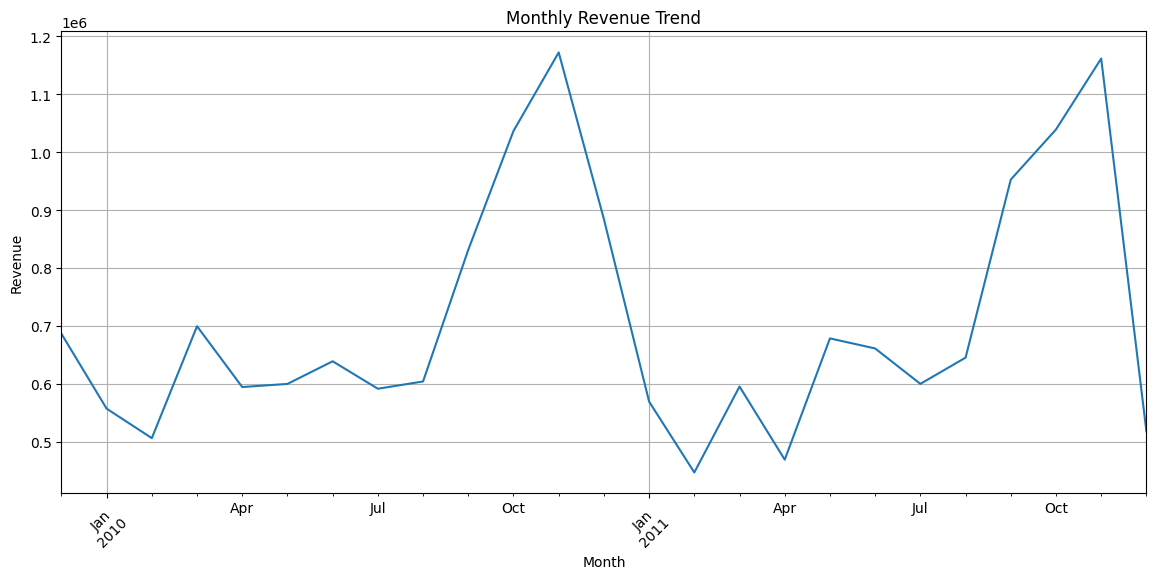

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

monthly_revenue.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()